# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [5]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

Esse conjunto de dados foi coletao de uma empresa  de telecom iraniana po 12 meses, com o objetivo de identificar quais clientes possuí maior probabilidade de cancelar os serviços da empresa. Ele possuí os atributos :  falhas em chamadas, frequência de SMS, número de reclamações, número de chamadas distintas, duração da assinatura, faixa etária, valor da cobrança, tipo de serviço, segundos de uso, status, frequência de uso e valor do cliente.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [7]:
display(df.head())
print(f'Dimensões do dataset: {df.shape}')

TARGET_COLUMN = 'Churn'
print(f'Valores unicos de {TARGET_COLUMN}: {df[TARGET_COLUMN].unique()}')
print(f'Quantidade de classes: {df[TARGET_COLUMN].nunique()}')

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


Dimensões do dataset: (3150, 14)
Valores unicos de Churn: [0 1]
Quantidade de classes: 2


O dataset possui 3150 amostras e 14 atributos no qual a variável alvo que é Churn esta incluso. Esse é um problema de clssificação binário pois a variável alvo possuí apenas dois valores possiveis (0 e 1).

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

Quantidade de amostras em cada classe: 
Churn
0    2655
1     495
Name: count, dtype: int64


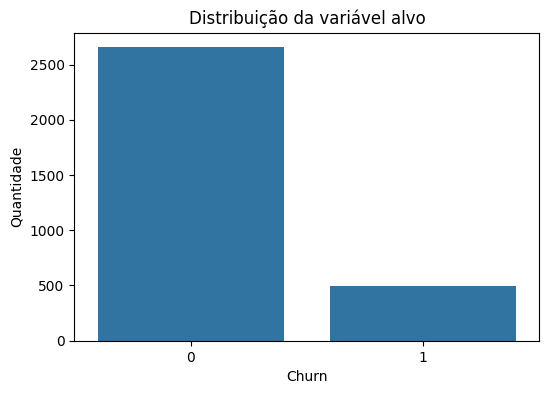

In [8]:
class_counts = df[TARGET_COLUMN].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x = TARGET_COLUMN, data = df)
plt.title('Distribuição da variável alvo')
plt.xlabel('Churn')
plt.ylabel('Quantidade')

plt.show

print(f'Quantidade de amostras em cada classe: \n{class_counts}')

O dataset é desbalenceado pois o número de clientes que não realizaram cancelamento (Churn) é muito maior do que o de realizaram.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

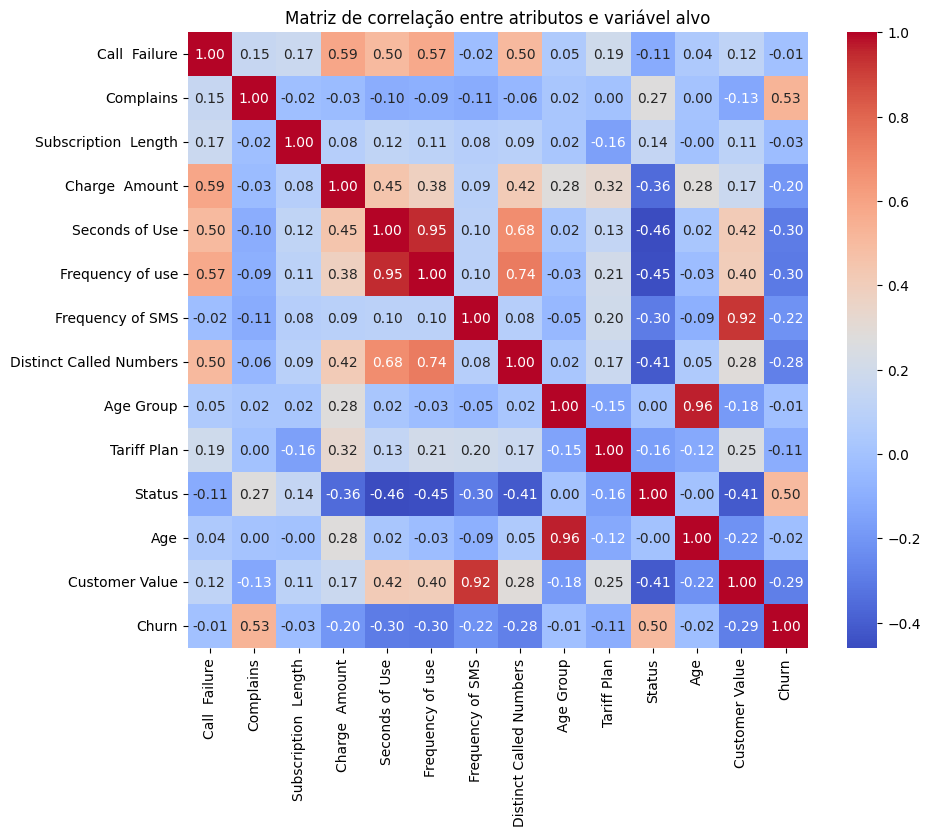

In [10]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlação entre atributos e variável alvo')
plt.show()


In [11]:
target_corr = corr_matrix[TARGET_COLUMN].sort_values(ascending=False)

print(target_corr)

Churn                      1.000000
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


Os atributos com maior correlação com a variável alvo são as reclamações com correlaçõe positiva(complains), o status também com correlação positiva, e frequencia de uso (frequency of use) com correlação negativa sendo assim os atributos mais influentos no problema.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

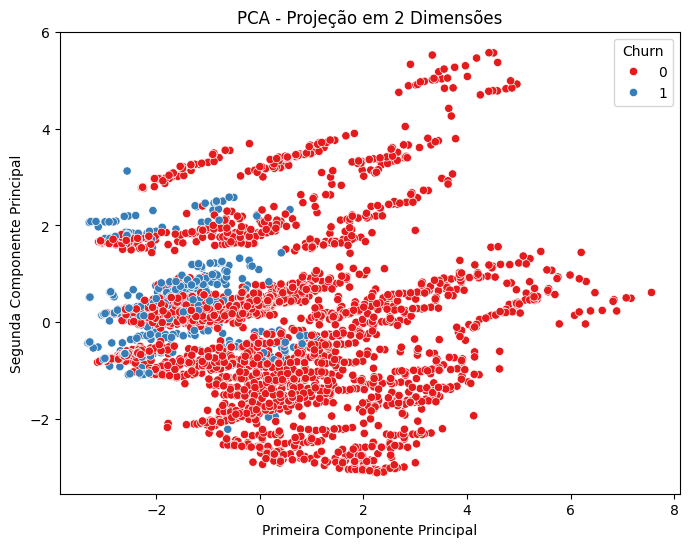

In [12]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Churn': y
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Churn',
    palette='Set1'
)

plt.title('PCA - Projeção em 2 Dimensões')
plt.xlabel('Primeira Componente Principal')
plt.ylabel('Segunda Componente Principal')

plt.show()

O gráfico mostra que há uma separaação parfical entre as classes, mas ainda há uma grande sobreposição entre os pontos das classes 0 e 1. A classe 1 concentra-se na região mais a esquerda do gráfico enquanto a classe 0 já esta mais distribuída pelo gráfico. Não da para identificar uma divisão clara entre os grupos o que indica que as suas duas componententes principais conseguem representar parte das diferenças entre as classes, mas não são suficientes para separar completamente os dados.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [13]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2520, 13)
X_test: (630, 13)
y_train: (2520,)
y_test: (630,)


A padronização é importante para equilibrar a contribuição dos atributos para o modelo. Os tributos do dataset possuem escalas diferentes, o StandardScaler transforma os dados para que a média seja igual a 0 e desvio padrão 1.

O fit é usado no treino apenas para evitar vazamento de dados, se o ajuste fosse aplicado nos testes as estatisticas seriam incoporadas ao treinamento, por isso no teste usamso o transform.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [14]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Número de iterações realizadas:", model.n_iter_)

Número de iterações realizadas: [42]


A regressão logística é um modelo de classificação supervisionada utilizado para prever a probabilidade de ocorrência de uma determinada classe. Nesse contexto, o modelo tem como objetivo prever se um cliente irá cancelar ou não o serviço da empresa (Churn).

Durante o treinamento, o modelo aprende padrões existentes nos dados a partir dos atributos do dataset, como número de reclamações, frequência de uso, tempo de assinatura e valor do cliente. Com isso, ele ajusta coeficientes para cada variável, buscando identificar quais características estão mais associadas ao cancelamento do serviço.

 As 42 iterações realizadas indica que o modelo convergiu corretamente, ou seja, o algoritmo conseguiu encontrar uma solução adequada após 42 iterações do processo de otimização. Isso significa que os parâmetros do modelo foram ajustados adequadamente para minimizar os erros de classificação nos dados de treino.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [19]:
y_proba = model.predict_proba(X_test_scaled)

print(y_proba[:50])

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]
 [9.85127149e-01 1.48728513e-02]
 [9.47613428e-01 5.23865722e-02]
 [9.95248532e-01 4.75146795e-03]
 [9.84226380e-01 1.57736196e-02]
 [7.38421683e-01 2.61578317e-01]
 [9.42979016e-01 5.70209840e-02]
 [7.21510843e-02 9.27848916e-01]
 [4.87845607e-01 5.12154393e-01]
 [9.89448379e-01 1.05516213e-02]
 [8.77900549e-01 1.22099451e-01]
 [9.94276786e-01 5.72321363e-03]
 [8.55297990e-01 1.44702010e-01]
 [8.61747078e-01 1.38252922e-01]
 [9.59316499e-01 4.06835012e-02]
 [7.08665662e-01 2.91334338e-01]
 [5.59243533e-01 4.40756467e-01]
 [7.21951027e-01 2.78048973e-01]
 [1.53671742e-01 8.46328258e-01]
 [7.54096675e-01 2.45903325e-01]
 [5.91823346e-01 4.08176654e-01]
 [7.057581

A primeira coluna representa a probabilidade do cliente não cancelar e a segunda de cancelar.
De maneira geral as previsões apresentam valores próximos a 1 para a primeira coluna ou seja ele tem quase certeza de que pertence a classe 0.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [20]:
y_scores = y_proba[:, 1]
y_pred_05 = (y_scores >= 0.5).astype(int)
y_pred_07 = (y_scores >= 0.7).astype(int)

print("Previsões com limiar 0.5:")
print(y_pred_05[:20])

print("\nPrevisões com limiar 0.7:")
print(y_pred_07[:20])


print("\nQuantidade de churns previstos:")
print("Limiar 0.5:", y_pred_05.sum())
print("Limiar 0.7:", y_pred_07.sum())

Previsões com limiar 0.5:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]

Previsões com limiar 0.7:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]

Quantidade de churns previstos:
Limiar 0.5: 60
Limiar 0.7: 42


O aumento do limiar fez com que o número de previsões caisse de 60 para 42. Isso impacta principalmente nos erro do modelo, com limiar em 0,5 o modelo fica mais sensível, indicando mais casos de cancelamento e isso pode aumentar os falsos positivos, em contra partida o limiar 0,7 tem o efeito contrário podendo dentão aumentar o número de falsos negativos.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [8]:
acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05)
rec_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)

print("Acurácia:", acc_05)
print("Precisão:", prec_05)
print("Recall:", rec_05)
print("F1-score:", f1_05)

cm_05 = confusion_matrix(y_test, y_pred_05)

print("\nMatriz de Confusão:")
print(cm_05)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_05))


NameError: name 'y_test' is not defined

In [ ]:
acc_07 = accuracy_score(y_test, y_pred_07)
prec_07 = precision_score(y_test, y_pred_07)
rec_07 = recall_score(y_test, y_pred_07)
f1_07 = f1_score(y_test, y_pred_07)

print("Acurácia:", acc_07)
print("Precisão:", prec_07)
print("Recall:", rec_07)
print("F1-score:", f1_07)

cm_07 = confusion_matrix(y_test, y_pred_07)

print("\nMatriz de Confusão:")
print(cm_07)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_07))

A precisão e o recall são as princiapis impactadas pelo limiar,  a acurácia menteve praticamnte igual indicando que a quantidade totals de acertos do modelo não mudou. CCom o limiar maior, o modelo passa a exigir maior confiança para classificar um cliente como churn, tornando as previsões positivas mais confiáveis (maior precisão). Porém, isso faz com que mais clientes que realmente realizariam churn deixem de ser identificados, reduzindo o recall.

Nesse problema, o recall foi a métrica mais impactada pela mudança do limiar, pois houve uma redução significativa na capacidade do modelo de detectar clientes que realmente cancelariam o serviço. Portanto, a escolha do limiar depende do objetivo do negócio, se for mais importante identificar o maior número possível de clientes em risco de churn, um limiar menor pode ser mais adequado, se o objetivo for reduzir alarmes falsos, um limiar maior pode ser preferível.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O dataset pertence ao domínio da biologia e geoprocessamentos, seu objetivo é identificar, entre sete tipos diferentes de cobertura florestal, qual é o tipo presente em cada área analisada, utilizando apenas variáveis cartográficas e ambientais, sem o uso de dados de sensoriamento remoto. Ele contém informações como elevação, orientação do terreno, declive, distâncias até hidrologia e estradas, índices de sombreamento em diferentes horários do dia e variáveis binárias relacionadas ao tipo de solo ee áreas de preservação ambiental.

In [9]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [10]:
display(df.head())

print(f'Dimensões do dataset: {df.shape}')

TARGET_COLUMN = 'Cover_Type'

print(f'Valores únicos de {TARGET_COLUMN}:')
print(df[TARGET_COLUMN].unique())

print(f'Quantidade de classes: {df[TARGET_COLUMN].nunique()}')

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


Dimensões do dataset: (58101, 55)
Valores únicos de Cover_Type:
[1 2 3 5 6 7 4]
Quantidade de classes: 7


O dataset possui 58.101 amostras e 55 atributos, considerando os 54 atributos de entrada e a variável alvo Cover_Type. A variável alvo representa o tipo de cobertura florestal da região analisada. Trata-se de um problema de classificação multiclasse, pois a variável alvo apresenta 7 valores únicos diferentes, correspondentes aos diferentes tipos de cobertura florestal existentes no conjunto de dados.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

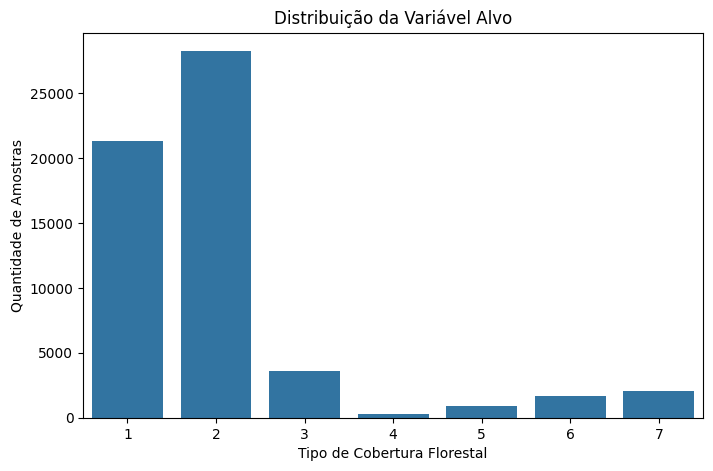

Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


In [11]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.countplot(x=TARGET_COLUMN, data=df)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Tipo de Cobertura Florestal')
plt.ylabel('Quantidade de Amostras')

plt.show()

print(class_counts)


Com base na distribuição das classes, o dataset é desbalanceado, pois existe uma grande diferença na quantidade de amostras entre os diferentes tipos de cobertura florestal. As classes 1 e 2 possuem a maior quantidade de exemplos, com 21.297 e 28.248 amostras, respectivamente, enquanto outras classes apresentam quantidades muito menores, como a classe 4, que possui apenas 259 amostras.
Essa diferença significativa na proporção entre as classes indica que o modelo pode acabar favorecendo as classes majoritárias durante o treinamento, tendo maior dificuldade em identificar corretamente as classes minoritárias. Portanto, trata-se de um problema de classificação multiclasse desbalanceado.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

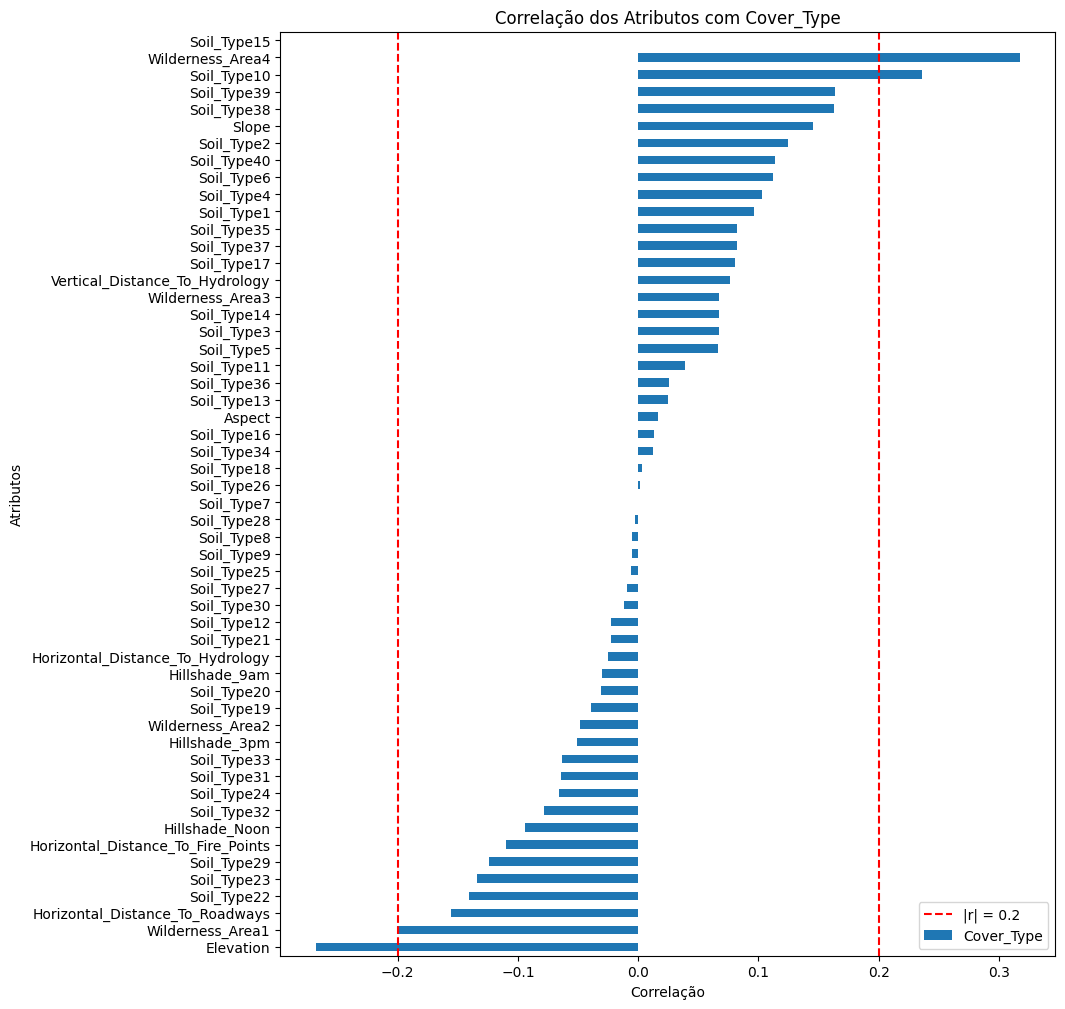

Elevation                            -0.268264
Wilderness_Area1                     -0.200715
Horizontal_Distance_To_Roadways      -0.155258
Soil_Type22                          -0.140253
Soil_Type23                          -0.133668
Soil_Type29                          -0.123732
Horizontal_Distance_To_Fire_Points   -0.109868
Hillshade_Noon                       -0.094159
Soil_Type32                          -0.078483
Soil_Type24                          -0.065993
Soil_Type31                          -0.064168
Soil_Type33                          -0.063686
Hillshade_3pm                        -0.050833
Wilderness_Area2                     -0.048265
Soil_Type19                          -0.039402
Soil_Type20                          -0.030760
Hillshade_9am                        -0.029857
Horizontal_Distance_To_Hydrology     -0.024854
Soil_Type21                          -0.022818
Soil_Type12                          -0.022214
Soil_Type30                          -0.011948
Soil_Type27  

In [12]:
corr_target = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN)

corr_sorted = corr_target.sort_values()

plt.figure(figsize=(10,12))

corr_sorted.plot(kind='barh')

plt.axvline(x=0.2, color='red', linestyle='--', label='|r| = 0.2')
plt.axvline(x=-0.2, color='red', linestyle='--')

plt.title('Correlação dos Atributos com Cover_Type')
plt.xlabel('Correlação')
plt.ylabel('Atributos')

plt.legend()
plt.show()


print(corr_sorted)

Com base nos valores de correlação, os atributos mais relevantes para o modelo são Wilderness_Area4 (0.318), Elevation (-0.268), Soil_Type10 (0.236) e Wilderness_Area1 (-0.201), pois ultrapassam o limiar de |r| = 0.2. Esses resultados indicam que variáveis relacionadas à altitude, tipo de solo e áreas de preservação possuem maior influência sobre o tipo de cobertura florestal.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

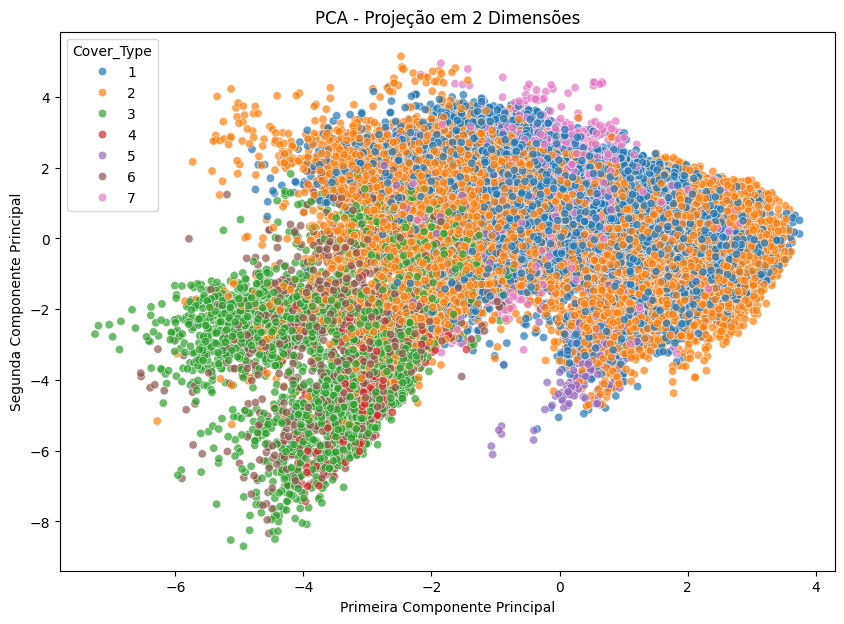

In [13]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cover_Type': y
})


plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cover_Type',
    palette='tab10',
    alpha=0.7
)

plt.title('PCA - Projeção em 2 Dimensões')
plt.xlabel('Primeira Componente Principal')
plt.ylabel('Segunda Componente Principal')

plt.show()

Com base no gráfico gerado pelo PCA, observa-se que algumas classes apresentam regiões parcialmente separadas, como as classes 3 e 6, que se concentram mais na parte inferior esquerda do gráfico. Entretanto, existe uma grande sobreposição entre várias classes, principalmente entre as classes 1 e 2, que aparecem distribuídas em praticamente toda a projeção. Isso indica que as duas primeiras componentes principais conseguem capturar parte da estrutura dos dados, mas não são suficientes para separar completamente todas as classes do problema multiclasse. Portanto, o dataset apresenta considerável complexidade e sobreposição entre grupos.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [14]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (46480, 54)
X_test: (11621, 54)
y_train: (46480,)
y_test: (11621,)


A validação cruzada (k-fold cross-validation) é importante porque avalia o modelo de forma mais confiável, utilizando diferentes divisões dos dados em várias iterações. Isso reduz o risco de resultados enviesados e ajuda a verificar a capacidade de generalização do modelo em novos dados. Neste caso, o conjunto de treino possui 46.480 amostras e o conjunto de teste 11.621, ambos com 54 atributos. A padronização também é importante para equilibrar a escala das variáveis durante o treinamento.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [15]:
acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_tr_scaled, y_tr)

    print(f"Fold {fold} - número de iterações: {model.n_iter_}")

    y_pred = model.predict(X_val_scaled)

    acc_scores.append(accuracy_score(y_val, y_pred))
    prec_scores.append(precision_score(y_val, y_pred, average='weighted'))
    rec_scores.append(recall_score(y_val, y_pred, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred, average='weighted'))

print("\nMédias das métricas:")
print("Acurácia média:", np.mean(acc_scores))
print("Precisão média:", np.mean(prec_scores))
print("Recall médio:", np.mean(rec_scores))
print("F1-score médio:", np.mean(f1_scores))

Fold 1 - número de iterações: [184]
Fold 2 - número de iterações: [179]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3 - número de iterações: [217]
Fold 4 - número de iterações: [205]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5 - número de iterações: [180]

Médias das métricas:
Acurácia média: 0.7259466437177281
Precisão média: 0.712596520992203
Recall médio: 0.7259466437177281
F1-score médio: 0.7156815554860636


O modelo de regressão logística multiclasse convergiu corretamente em todos os folds, realizando entre 179 e 217 iterações. As métricas médias obtidas foram aproximadamente 72,6% de acurácia e 71,6% de F1-score, indicando desempenho razoável no problema.

O papel do modelo é aprender padrões nos atributos ambientais e geográficos, como altitude, declive, tipo de solo e áreas de preservação, para prever corretamente o tipo de cobertura florestal de cada amostra. Durante o treinamento, o modelo aprende relações entre essas variáveis e as diferentes classes do dataset para realizar a classificação multiclasse.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(X_test_scaled)

print(y_proba[:10])

print("Número de iterações:", model.n_iter_)

[[4.56718481e-01 5.23084183e-01 6.39284902e-05 9.02739482e-05
  3.08497108e-03 8.75511493e-05 1.68706112e-02]
 [3.83918030e-02 4.50020779e-01 1.52924004e-01 4.51295588e-04
  1.32717895e-02 3.44410291e-01 5.30037883e-04]
 [2.24398140e-01 7.34051460e-01 3.88706013e-03 3.30029562e-04
  2.16104420e-02 1.14592292e-02 4.26363915e-03]
 [2.37864629e-01 7.45047850e-01 9.41347793e-04 8.67305481e-05
  1.12881709e-02 2.02220183e-03 2.74906990e-03]
 [1.15367020e-01 7.28306959e-01 7.65292658e-03 1.30015908e-04
  3.49590343e-02 1.13242686e-01 3.41358172e-04]
 [5.98901124e-01 3.89037776e-01 4.27448192e-05 3.69337999e-05
  1.48601331e-03 1.46149299e-04 1.03492585e-02]
 [3.86811416e-01 5.97202619e-01 1.34503125e-03 7.00592122e-05
  4.97645433e-03 3.74243168e-03 5.85198858e-03]
 [2.40762122e-01 7.41701560e-01 4.31472757e-04 1.06170159e-04
  1.47183110e-02 6.29063342e-04 1.65130025e-03]
 [4.73949376e-01 5.19709426e-01 1.23814444e-04 7.48650947e-05
  1.55892486e-03 3.41763193e-04 4.24183037e-03]
 [4.297104

O modelo convergiu corretamente após 104 iterações. As probabilidades previstas indicam a chance de cada amostra pertencer a cada uma das 7 classes de Cover_Type, sendo que cada coluna representa uma classe diferente. Algumas previsões apresentam alta confiança, com probabilidades acima de 70% para uma classe específica, enquanto outras mostram valores mais próximos entre diferentes classes, indicando maior incerteza do modelo. De forma geral, quanto mais próximo de 1 estiver o valor de uma classe, maior é a confiança da previsão realizada.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_no_reg = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

model_no_reg.fit(X_train_scaled, y_train)

y_proba_no_reg = model_no_reg.predict_proba(X_test_scaled)

print(y_proba_no_reg[:10])

print("Número de iterações:", model_no_reg.n_iter_)

[[4.77904679e-01 5.12566466e-01 1.21550291e-08 1.45027441e-08
  1.65999685e-03 4.64212188e-09 7.86882759e-03]
 [3.10922536e-02 4.29935336e-01 1.07349805e-01 1.49004717e-06
  1.29503034e-02 4.18670810e-01 2.53819741e-09]
 [1.99335256e-01 7.75793729e-01 9.01252328e-04 4.87469950e-07
  2.25777668e-02 1.31798815e-03 7.35199359e-05]
 [2.15509517e-01 7.71855919e-01 9.51777126e-07 1.47277533e-07
  1.23989557e-02 1.37180572e-04 9.73280464e-05]
 [1.00909537e-01 7.62007905e-01 3.63551631e-03 1.01374672e-06
  3.05137638e-02 1.02932115e-01 1.48869652e-07]
 [6.32887812e-01 3.58900381e-01 4.75006268e-09 9.66934868e-10
  6.66480241e-04 4.87726799e-09 7.54531529e-03]
 [3.87671461e-01 6.07607821e-01 1.36036089e-04 2.12422164e-07
  3.82541405e-03 4.45765235e-04 3.13289579e-04]
 [2.22915955e-01 7.62972196e-01 1.36198546e-07 2.27804606e-11
  1.40150838e-02 5.44122349e-08 9.65743216e-05]
 [4.60567125e-01 5.38919742e-01 9.64005129e-07 4.28347116e-08
  2.90376350e-06 1.45727145e-07 5.09076617e-04]
 [8.670166

O modelo sem regularização convergiu corretamente após 218 iterações, utilizando mais iterações que o modelo com regularização L2. As probabilidades previstas representam a chance de cada amostra pertencer às 7 classes do problema. Comparado ao modelo regularizado, o modelo sem regularização produziu probabilidades mais extremas, com valores muito próximos de 0 e 1, indicando previsões mais confiantes, porém com maior risco de overfitting.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [18]:
confidence_reg = np.mean(np.max(y_proba, axis=1))

confidence_no_reg = np.mean(np.max(y_proba_no_reg, axis=1))

print("Confiança média - com regularização:", confidence_reg)
print("Confiança média - sem regularização:", confidence_no_reg)

Confiança média - com regularização: 0.7024909029483848
Confiança média - sem regularização: 0.7275706595353355


O modelo sem regularização apresentou probabilidades mais concentradas em uma única classe e maior confiança média, enquanto o modelo com regularização L2 apresentou previsões mais equilibradas e confiança média menor. Isso indica que o modelo sem regularização faz previsões mais extremas, podendo apresentar sinais de overfitting, enquanto a regularização ajuda a tornar o modelo mais estável e com melhor capacidade de generalização.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [19]:
y_pred_reg = model.predict(X_test_scaled)

print("===== MODELO COM REGULARIZAÇÃO =====")
print(classification_report(y_test, y_pred_reg))

y_pred_no_reg = model_no_reg.predict(X_test_scaled)

print("===== MODELO SEM REGULARIZAÇÃO =====")
print(classification_report(y_test, y_pred_no_reg))

===== MODELO COM REGULARIZAÇÃO =====
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

===== MODELO SEM REGULARIZAÇÃO =====
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
    

Os dois modelos apresentaram desempenho semelhante, com acurácia entre 72% e 73%. As classes majoritárias (1 e 2) tiveram os melhores resultados, enquanto classes minoritárias apresentaram desempenho mais baixo. O modelo sem regularização obteve resultados ligeiramente melhores em algumas classes e maior acurácia geral, porém pode apresentar maior risco de overfitting. Já o modelo com regularização L2 apresentou comportamento mais estável e controlado.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

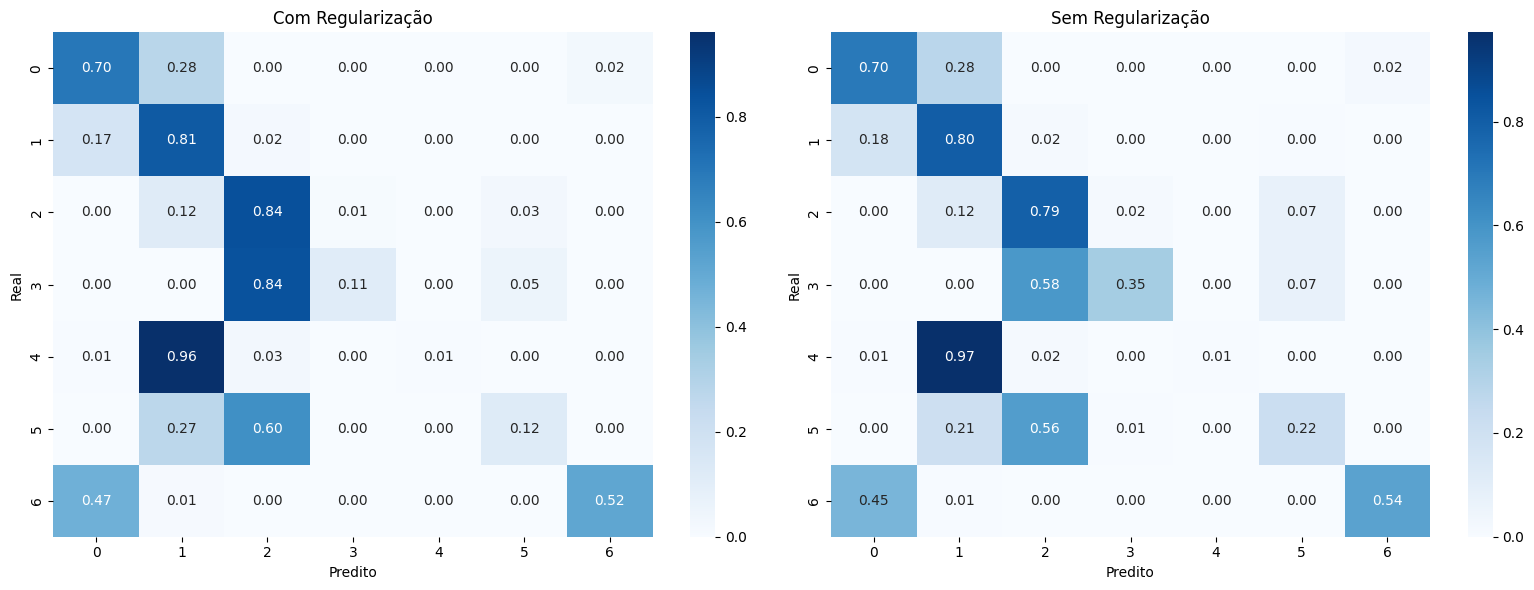

In [20]:
cm_reg = confusion_matrix(
    y_test,
    y_pred_reg,
    normalize='true'
)

cm_no_reg = confusion_matrix(
    y_test,
    y_pred_no_reg,
    normalize='true'
)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(
    cm_reg,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title('Com Regularização')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(
    cm_no_reg,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[1]
)

axes[1].set_title('Sem Regularização')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

As matrizes de confusão mostram que as classes 1, 2 e 3 foram as melhor classificadas pelos dois modelos, enquanto as classes minoritárias apresentaram maior confusão. O modelo sem regularização teve melhor desempenho em algumas classes menores, como a classe 4, enquanto o modelo com regularização L2 apresentou comportamento mais estável e conservador. De forma geral, os dois modelos tiveram desempenho semelhante, mas o modelo sem regularização conseguiu separar melhor algumas classes específicas.